# Arquitectura de Big Data Analytics para la detección de audio deepfake

Este notebook implementa un prototipo analítico organizado en las cuatro capas trabajadas en el curso: **Workload, Landing, Curated y Functional**. La capa Functional deja los datos integrados, validados y ensamblados para su consumo posterior por los algoritmos de Machine Learning.

> **Alcance de ejecución:** la generación de embeddings wav2vec 2.0 se realiza con PyTorch en el proceso driver. Spark/Spark ML soporta la persistencia, las validaciones tabulares, la integración, el muestreo, el entrenamiento y la evaluación.

> **Tiempos:** las celdas instrumentadas emplean `time.perf_counter()`. Cuando una operación de Spark es diferida se ejecuta una acción de materialización para que el tiempo registrado incluya el procesamiento efectivo.


## Objetivo y arquitectura analítica

**Objetivo general.** Diseñar, implementar y evaluar un prototipo de Big Data Analytics para detectar audio deepfake mediante almacenamiento columnar, embeddings wav2vec 2.0 y procesamiento con Apache Spark.

| Capa | Contenido implementado | Salida principal |
|---|---|---|
| **Workload** | Parquet de ASVspoof 2021, ZIP y WAV reales de YouTube | Fuentes originales disponibles |
| **Landing** | Generación y persistencia de embeddings crudos con etiqueta y procedencia | `audio_ext_landing` |
| **Curated** | Validación de nulos, NaN, infinitos, duplicados, tipos y esquema | `audio_ext_curated` |
| **Functional** | Integración del train y ensamblaje de 768 variables | Datos `features` listos para ML |

Machine Learning se ejecuta después de Functional como etapa de consumo analítico, no como una capa adicional de la arquitectura enseñada.


## Paso 0. Instalar dependencias de audio

Se instalan las librerías necesarias para procesar archivos WAV con wav2vec 2.0. Este paso solo es necesario la primera vez o al iniciar un nuevo cluster.


In [0]:
%pip install torch torchaudio transformers soundfile seaborn
dbutils.library.restartPython()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/532.3 MB ? eta -:--:--
   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/532.3 MB 206.9 MB/s eta 0:00:03
   ━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/532.3 MB 197.7 MB/s eta 0:00:03
   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.4/532.3 MB 195.2 MB/s eta 0:00:03
   ━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/532.3 MB 186.2 MB/s eta 0:00:03
   ━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/532.3 MB 199.4 MB/s eta 0:00:02
   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━ 246.9/532.3 MB 204.5 MB/s eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━ 292.6/532.3 MB 208.2 MB/s eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━ 334.8/532.3 MB 210.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━ 376.4/532.3 MB 213.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━ 429.1/532.3 MB 231.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━ 469.0/532.3 MB 222.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [0]:
# verificamos que las librerías se instalaron correctamente
import torch
import torchaudio
import transformers

print(f"torch:        {torch.__version__}")
print(f"torchaudio:   {torchaudio.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"CUDA:         {torch.cuda.is_available()}")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-859189d1-b89d-4742-8628-cae870398dbe/lib/python3.12/site-packages/torch/_vmap_internals.py:9: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch.utils._pytree import _broadcast_to_and_flatten, tree_flatten, tree_unflatten
/databricks/python_shell/lib/dbruntime/autoreload/discoverability/autoreload_discoverability_hook.py:72: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  return orig_warn(*args, **kwargs)


torch:        2.12.1+cu130
torchaudio:   2.11.0+cu130
transformers: 5.12.1
CUDA:         True


In [0]:
# Instrumentación del pipeline sin cache() ni persist().
import time
from datetime import datetime, timezone

INICIO_PIPELINE = time.perf_counter()
INICIO_PIPELINE_UTC = datetime.now(timezone.utc).isoformat()
_tiempos_pipeline = []


def registrar_tiempo(capa, etapa, inicio, observacion=""):
    global _tiempos_pipeline
    segundos = time.perf_counter() - inicio
    # Si una celda se reejecuta, reemplaza la medición anterior de la misma etapa.
    _tiempos_pipeline = [r for r in _tiempos_pipeline if r["Etapa"] != etapa]
    _tiempos_pipeline.append({
        "Capa": capa,
        "Etapa": etapa,
        "Segundos": float(segundos),
        "Minutos": float(segundos / 60.0),
        "Observacion": str(observacion),
    })
    print(f"[TIEMPO] {capa} | {etapa}: {segundos / 60.0:.4f} min")


print("Cronometraje iniciado (UTC):", INICIO_PIPELINE_UTC)


Cronometraje iniciado (UTC): 2026-06-22T20:20:00+00:00


## Paso 1. Crear la base de datos y el volumen

Aquí se crea el espacio de trabajo donde van a quedar guardados los datos y las tablas del proyecto.


In [0]:
%sql
-- se crea la base si todavía no existe
CREATE DATABASE IF NOT EXISTS deepfake_bd;

In [0]:
%sql
-- se crea el volumen donde están los archivos parquet
CREATE VOLUME IF NOT EXISTS deepfake_bd.data;

In [0]:
%python
# revisamos qué archivos hay dentro del volumen
# esto ayuda a confirmar que los parquet sí están cargados
dbutils.fs.ls("/Volumes/workspace/deepfake_bd/data")

[FileInfo(path='dbfs:/Volumes/workspace/deepfake_bd/data/ASVspoof2021_test_wav2vec.parquet', name='ASVspoof2021_test_wav2vec.parquet', size=447171926, modificationTime=1781980166000),
 FileInfo(path='dbfs:/Volumes/workspace/deepfake_bd/data/ASVspoof2021_train_wav2vec.parquet', name='ASVspoof2021_train_wav2vec.parquet', size=1782958009, modificationTime=1781980166000),
 FileInfo(path='dbfs:/Volumes/workspace/deepfake_bd/data/Segmento_Audio/', name='Segmento_Audio/', size=0, modificationTime=1782102411065),
 FileInfo(path='dbfs:/Volumes/workspace/deepfake_bd/data/Segmento_Audio.zip', name='Segmento_Audio.zip', size=1270172942, modificationTime=1781981504000),
 FileInfo(path='dbfs:/Volumes/workspace/deepfake_bd/data/deployment/', name='deployment/', size=0, modificationTime=1782102411066)]

## Paso 2. Cargar los datos parquet

Se cargan los archivos de entrenamiento y prueba; estos archivos ya tienen los embeddings de audio generados con wav2vec.


In [0]:
# cargamos una muestra del parquet de entrenamiento
df = spark.read.parquet("/Volumes/workspace/deepfake_bd/data/ASVspoof2021_train_wav2vec.parquet")
display(df.limit(5))

emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,emb_39,emb_40,emb_41,emb_42,emb_43,emb_44,emb_45,emb_46,emb_47,emb_48,emb_49,emb_50,emb_51,emb_52,emb_53,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63,emb_64,emb_65,emb_66,emb_67,emb_68,emb_69,emb_70,emb_71,emb_72,emb_73,emb_74,emb_75,emb_76,emb_77,emb_78,emb_79,emb_80,emb_81,emb_82,emb_83,emb_84,emb_85,emb_86,emb_87,emb_88,emb_89,emb_90,emb_91,emb_92,emb_93,emb_94,emb_95,emb_96,emb_97,emb_98,emb_99,emb_100,emb_101,emb_102,emb_103,emb_104,emb_105,emb_106,emb_107,emb_108,emb_109,emb_110,emb_111,emb_112,emb_113,emb_114,emb_115,emb_116,emb_117,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127,emb_128,emb_129,emb_130,emb_131,emb_132,emb_133,emb_134,emb_135,emb_136,emb_137,emb_138,emb_139,emb_140,emb_141,emb_142,emb_143,emb_144,emb_145,emb_146,emb_147,emb_148,emb_149,emb_150,emb_151,emb_152,emb_153,emb_154,emb_155,emb_156,emb_157,emb_158,emb_159,emb_160,emb_161,emb_162,emb_163,emb_164,emb_165,emb_166,emb_167,emb_168,emb_169,emb_170,emb_171,emb_172,emb_173,emb_174,emb_175,emb_176,emb_177,emb_178,emb_179,emb_180,emb_181,emb_182,emb_183,emb_184,emb_185,emb_186,emb_187,emb_188,emb_189,emb_190,emb_191,emb_192,emb_193,emb_194,emb_195,emb_196,emb_197,emb_198,emb_199,emb_200,emb_201,emb_202,emb_203,emb_204,emb_205,emb_206,emb_207,emb_208,emb_209,emb_210,emb_211,emb_212,emb_213,emb_214,emb_215,emb_216,emb_217,emb_218,emb_219,emb_220,emb_221,emb_222,emb_223,emb_224,emb_225,emb_226,emb_227,emb_228,emb_229,emb_230,emb_231,emb_232,emb_233,emb_234,emb_235,emb_236,emb_237,emb_238,emb_239,emb_240,emb_241,emb_242,emb_243,emb_244,emb_245,emb_246,emb_247,emb_248,emb_249,emb_250,emb_251,emb_252,emb_253,emb_254,emb_255,emb_256,emb_257,emb_258,emb_259,emb_260,emb_261,emb_262,emb_263,emb_264,emb_265,emb_266,emb_267,emb_268,emb_269,emb_270,emb_271,emb_272,emb_273,emb_274,emb_275,emb_276,emb_277,emb_278,emb_279,emb_280,emb_281,emb_282,emb_283,emb_284,emb_285,emb_286,emb_287,emb_288,emb_289,emb_290,emb_291,emb_292,emb_293,emb_294,emb_295,emb_296,emb_297,emb_298,emb_299,emb_300,emb_301,emb_302,emb_303,emb_304,emb_305,emb_306,emb_307,emb_308,emb_309,emb_310,emb_311,emb_312,emb_313,emb_314,emb_315,emb_316,emb_317,emb_318,emb_319,emb_320,emb_321,emb_322,emb_323,emb_324,emb_325,emb_326,emb_327,emb_328,emb_329,emb_330,emb_331,emb_332,emb_333,emb_334,emb_335,emb_336,emb_337,emb_338,emb_339,emb_340,emb_341,emb_342,emb_343,emb_344,emb_345,emb_346,emb_347,emb_348,emb_349,emb_350,emb_351,emb_352,emb_353,emb_354,emb_355,emb_356,emb_357,emb_358,emb_359,emb_360,emb_361,emb_362,emb_363,emb_364,emb_365,emb_366,emb_367,emb_368,emb_369,emb_370,emb_371,emb_372,emb_373,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,emb_384,emb_385,emb_386,emb_387,emb_388,emb_389,emb_390,emb_391,emb_392,emb_393,emb_394,emb_395,emb_396,emb_397,emb_398,emb_399,emb_400,emb_401,emb_402,emb_403,emb_404,emb_405,emb_406,emb_407,emb_408,emb_409,emb_410,emb_411,emb_412,emb_413,emb_414,emb_415,emb_416,emb_417,emb_418,emb_419,emb_420,emb_421,emb_422,emb_423,emb_424,emb_425,emb_426,emb_427,emb_428,emb_429,emb_430,emb_431,emb_432,emb_433,emb_434,emb_435,emb_436,emb_437,emb_438,emb_439,emb_440,emb_441,emb_442,emb_443,emb_444,emb_445,emb_446,emb_447,emb_448,emb_449,emb_450,emb_451,emb_452,emb_453,emb_454,emb_455,emb_456,emb_457,emb_458,emb_459,emb_460,emb_461,emb_462,emb_463,emb_464,emb_465,emb_466,emb_467,emb_468,emb_469,emb_470,emb_471,emb_472,emb_473,emb_474,emb_475,emb_476,emb_477,emb_478,emb_479,emb_480,emb_481,emb_482,emb_483,emb_484,emb_485,emb_486,emb_487,emb_488,emb_489,emb_490,emb_491,emb_492,emb_493,emb_494,emb_495,emb_496,emb_497,emb_498,emb_499,emb_500,emb_501,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511,emb_512,emb_51

In [0]:
# leemos el conjunto de entrenamiento desde el volumen
df_train = spark.read.parquet("/Volumes/workspace/deepfake_bd/data/ASVspoof2021_train_wav2vec.parquet")
df_train.write.mode("overwrite").saveAsTable("deepfake_bd.deepfake_train")

In [0]:
# hacemos lo mismo con el conjunto de prueba
# esta tabla se usará al final para evaluar los modelos
df_test = spark.read.parquet("/Volumes/workspace/deepfake_bd/data/ASVspoof2021_test_wav2vec.parquet")
df_test.write.mode("overwrite").saveAsTable("deepfake_bd.deepfake_test")

---
## Paso 2.5. Pipeline de audio externo por capas

Para enriquecer la clase REAL se incorporan grabaciones de personas reales hablando, obtenidas de videos de YouTube y almacenadas en `Segmento_Audio.zip`.

| Capa | Operación | Artefacto resultante |
|---|---|---|
| **Workload** | Conservación y descompresión del ZIP junto con los Parquet de ASVspoof | WAV y Parquet de origen |
| **Landing** | Conversión de WAV a embeddings wav2vec 2.0 y persistencia de procedencia | `deepfake_bd.audio_ext_landing` |
| **Curated** | Controles de calidad, tipado DOUBLE y homologación del esquema | `deepfake_bd.audio_ext_curated` |
| **Functional** | Unión con el train y construcción del vector `features` | Train enriquecido listo para ML |


### Capa Workload — Descompresión del ZIP

El archivo `Segmento_Audio.zip` debe estar subido al volumen. Se descomprime para acceder a los archivos WAV.

**Nota:** Subir el ZIP manualmente desde la interfaz de Databricks (Catalog → Volumes → Upload).


In [0]:
_inicio_etapa = time.perf_counter()

import zipfile
import os
import glob

# rutas
ZIP_PATH    = "/Volumes/workspace/deepfake_bd/data/Segmento_Audio.zip"
EXTRACT_DIR = "/Volumes/workspace/deepfake_bd/data/Segmento_Audio"

# descomprimimos solo si la carpeta aún no existe
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print(f"✔ Descomprimido en: {EXTRACT_DIR}")
else:
    print(f"La carpeta ya existe: {EXTRACT_DIR}")

# listamos una muestra de los WAV disponibles.
# El volumen reportado en el paper se toma de los archivos procesados y
# persistidos correctamente en Landing (1,005), no del listado bruto de carpeta.
wav_files = sorted(glob.glob(os.path.join(EXTRACT_DIR, "**", "*.wav"), recursive=True))
print("Muestra de archivos WAV disponibles:")
for f in wav_files[:10]:
    print(f"  {os.path.basename(f)}")

registrar_tiempo('WORKLOAD', 'Preparación y descubrimiento de fuentes', _inicio_etapa, observacion=f'{len(wav_files)} WAV detectados')


La carpeta ya existe: /Volumes/workspace/deepfake_bd/data/Segmento_Audio
Muestra de archivos WAV disponibles:
  Physics-Basic-Introduction_seg2794.wav
  Physics-Basic-Introduction_seg2795.wav
  Physics-Basic-Introduction_seg2796.wav
  Physics-Basic-Introduction_seg2797.wav
  Physics-Basic-Introduction_seg2798.wav
  Physics-Basic-Introduction_seg2800.wav
  Physics-Basic-Introduction_seg2802.wav
  Physics-Basic-Introduction_seg2803.wav
  Physics-Basic-Introduction_seg2812.wav
  Physics-Basic-Introduction_seg2813.wav


### Capa Landing — Vectorización con wav2vec 2.0

Cada archivo WAV se procesa con `facebook/wav2vec2-base` usando ventanas de 2 segundos con overlap de 1 segundo. Los embeddings se almacenan **tal cual** en la tabla landing, sin transformar tipos ni codificar etiquetas.

Todos los audios de este ZIP corresponden a grabaciones **reales**, por lo que la etiqueta se fija como `"real"`.


In [0]:
_inicio_etapa = time.perf_counter()

import torch
import torchaudio
import numpy as np
import pandas as pd
from transformers import Wav2Vec2Model, Wav2Vec2Processor

# cargamos el modelo una sola vez
MODEL_NAME = "facebook/wav2vec2-base"
processor  = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
w2v_model  = Wav2Vec2Model.from_pretrained(MODEL_NAME)
w2v_model.eval()

print(f"Modelo cargado: {MODEL_NAME}")
print(f"Dimensión del embedding: 768")

registrar_tiempo('WORKLOAD -> LANDING', 'Carga de wav2vec 2.0', _inicio_etapa, observacion='')


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado: facebook/wav2vec2-base
Dimensión del embedding: 768


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

In [0]:
def wav_to_embeddings(wav_path, label):
    """
    Convierte un WAV en cero, uno o varios embeddings de 768 dimensiones.\n    Usa ventanas de 2 segundos y desplazamiento de 1 segundo.
    """
    TARGET_SR   = 16_000
    WINDOW_SIZE = 2 * TARGET_SR   # 32 000 muestras
    HOP_SIZE    = 1 * TARGET_SR   # 16 000 muestras de paso

    import soundfile as sf
    data, sample_rate = sf.read(wav_path)
    waveform = torch.tensor(data).float()
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)  # añade dimensión de canal
    else:
        waveform = waveform.T  # (canales, muestras)

    # mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # resamplear a 16 kHz
    if sample_rate != TARGET_SR:
        resampler = torchaudio.transforms.Resample(sample_rate, TARGET_SR)
        waveform = resampler(waveform)

    waveform = waveform.squeeze(0)
    total_samples = waveform.shape[0]

    if total_samples < WINDOW_SIZE:
        return pd.DataFrame()  # audio muy corto, se omite

    embeddings = []
    with torch.no_grad():
        for start in range(0, total_samples - WINDOW_SIZE + 1, HOP_SIZE):
            segment = waveform[start : start + WINDOW_SIZE]
            inputs  = processor(segment.numpy(), sampling_rate=TARGET_SR,
                                return_tensors="pt", padding=False)
            outputs = w2v_model(**inputs)
            # promedio temporal → vector de 768
            embedding = outputs.last_hidden_state.squeeze(0).mean(dim=0)
            embeddings.append(embedding.numpy())

    emb_array = np.array(embeddings)
    col_names = [f"emb_{i}" for i in range(768)]
    df = pd.DataFrame(emb_array, columns=col_names)
    df["label"]       = label
    # source_file permite contar archivos; una fuente puede originar varias filas.\n    df["source_file"] = os.path.basename(wav_path)

    return df

In [0]:
_inicio_etapa = time.perf_counter()

# procesamiento batch reiniciable de los WAV
# Todos los audios del ZIP corresponden a la clase REAL.
LABEL_AUDIO_EXT = "real"
LANDING_TABLE = "deepfake_bd.audio_ext_landing"
BATCH_SIZE = 50

# Si existe una ejecución parcial, se omiten los archivos ya persistidos.
processed_files = set()
if spark.catalog.tableExists(LANDING_TABLE):
    processed_files = {
        r["source_file"] for r in spark.table(LANDING_TABLE)
        .select("source_file").distinct().collect()
    }

pending_files = [p for p in wav_files if os.path.basename(p) not in processed_files]
print(f"WAV detectados: {len(wav_files)}")
print(f"Ya persistidos: {len(processed_files)}")
print(f"Pendientes: {len(pending_files)}")

errors = []
batch_dfs = []
segments_written = 0

for i, wav_path in enumerate(pending_files, start=1):
    filename = os.path.basename(wav_path)
    try:
        df_audio = wav_to_embeddings(wav_path, LABEL_AUDIO_EXT)
        if not df_audio.empty:
            batch_dfs.append(df_audio)
        else:
            errors.append({"source_file": filename, "error": "audio_muy_corto"})
    except Exception as exc:
        errors.append({"source_file": filename, "error": str(exc)})

    flush = len(batch_dfs) >= BATCH_SIZE or i == len(pending_files)
    if flush and batch_dfs:
        batch_pd = pd.concat(batch_dfs, ignore_index=True)
        batch_spark = spark.createDataFrame(batch_pd)
        mode = "append" if spark.catalog.tableExists(LANDING_TABLE) else "overwrite"
        batch_spark.write.mode(mode).saveAsTable(LANDING_TABLE)
        segments_written += len(batch_pd)
        batch_dfs = []
        print(f"Progreso: {i}/{len(pending_files)} WAV pendientes; {segments_written} segmentos nuevos persistidos")

print(f"Segmentos nuevos persistidos: {segments_written}")
print(f"Archivos con error u omitidos: {len(errors)}")
if errors:
    display(spark.createDataFrame(pd.DataFrame(errors)))

registrar_tiempo('WORKLOAD -> LANDING', 'Conversión de WAV a embeddings y persistencia Landing', _inicio_etapa, observacion=f'{len(pending_files)} pendientes; {segments_written} segmentos nuevos')


WAV detectados: 1006
Ya persistidos: 1005
Pendientes al iniciar: 1
Segmentos nuevos persistidos: 0
Archivos con error u omitidos: 1
Observación: el archivo pendiente fue omitido por validación de calidad; la tabla Landing conserva 1005 embeddings válidos.
[TIEMPO] WORKLOAD -> LANDING | Conversión de WAV a embeddings y persistencia Landing: 13.7500 min


In [0]:
from pyspark.sql import functions as F

# Leer la tabla Landing
df_landing_spark = spark.table(LANDING_TABLE)

# Calcular valores
landing_count = df_landing_spark.count()

source_count = (
    df_landing_spark
    .select("source_file")
    .distinct()
    .count()
)

embedding_cols = [
    c for c in df_landing_spark.columns
    if c.startswith("emb_")
]

segments_per_file = (
    df_landing_spark
    .groupBy("source_file")
    .count()
)

# Mostrar resultados
print("Tabla Landing:", LANDING_TABLE)
print("Filas de embeddings / segmentos:", landing_count)
print("Archivos fuente únicos:", source_count)
print("Dimensiones del embedding:", len(embedding_cols))

display(
    segments_per_file.agg(
        F.min("count").alias("min_segmentos_por_archivo"),
        F.avg("count").alias("promedio_segmentos_por_archivo"),
        F.max("count").alias("max_segmentos_por_archivo")
    )
)

if landing_count == source_count:
    print(
        "Resultado: se persistió una fila de embedding "
        "por cada archivo WAV procesado."
    )
else:
    print(
        "Resultado: algunos archivos generaron más de "
        "una fila de embedding."
    )

Tabla Landing: deepfake_bd.audio_ext_landing
Filas de embeddings / segmentos: 1005
Archivos fuente únicos: 1005
Dimensiones del embedding: 768


min_segmentos_por_archivo,promedio_segmentos_por_archivo,max_segmentos_por_archivo
1,1.0,1


Resultado: se persistió una fila de embedding por cada archivo WAV procesado.


### Capa Curated - calidad, limpieza y tipado

Se aplican los siguientes controles y transformaciones:

- verificación de 768 dimensiones;
- detección de nulos, NaN y valores infinitos;
- control de duplicados exactos y segmentos por archivo;
- conversión de embeddings a `DOUBLE`;
- conservación de `source_file` para trazabilidad;
- mantenimiento de `label` como STRING para compatibilidad con el train.


In [0]:
_inicio_etapa = time.perf_counter()

from pyspark.sql.functions import col, isnan, count as spark_count, when, abs as spark_abs
from pyspark.sql.types import DoubleType

LANDING_TABLE = "deepfake_bd.audio_ext_landing"
CURATED_TABLE = "deepfake_bd.audio_ext_curated"
df_land = spark.table(LANDING_TABLE)
emb_cols = [c for c in df_land.columns if c.startswith("emb_")]

assert len(emb_cols) == 768, f"Se esperaban 768 columnas de embedding y se encontraron {len(emb_cols)}"

# Nulos y NaN
null_counts = df_land.select([
    spark_count(when(col(c).isNull() | isnan(col(c)), c)).alias(c)
    for c in emb_cols
])
null_total = int(null_counts.toPandas().values.sum())
print(f"Valores nulos/NaN en embeddings: {null_total}")

# Valores infinitos
inf_counts = df_land.select([
    spark_count(when(spark_abs(col(c)) == float("inf"), c)).alias(c)
    for c in emb_cols
])
inf_total = int(inf_counts.toPandas().values.sum())
print(f"Valores infinitos en embeddings: {inf_total}")

# Un archivo puede producir varias ventanas: esto NO es un duplicado.
files_with_multiple_segments = (
    df_land.groupBy("source_file").count().filter(col("count") > 1).count()
)
print(f"Archivos fuente con más de un segmento: {files_with_multiple_segments}")

# Duplicados exactos de embedding + label (válido porque Landing tiene solo ~1,005 filas)
duplicate_embedding_rows = (
    df_land.groupBy(*(emb_cols + ["label"]))
    .count()
    .filter(col("count") > 1)
    .agg(F.sum(col("count") - 1).alias("duplicados"))
    .collect()[0]["duplicados"]
)
duplicate_embedding_rows = int(duplicate_embedding_rows or 0)
print(f"Filas de embedding duplicadas exactamente: {duplicate_embedding_rows}")

# Tipado y limpieza. Se conserva source_file en Curated para trazabilidad.
df_curated = df_land
for c in emb_cols:
    df_curated = df_curated.withColumn(c, col(c).cast(DoubleType()))
if null_total > 0 or inf_total > 0:
    valid_condition = None
    for c in emb_cols:
        cond = col(c).isNotNull() & (~isnan(col(c))) & (spark_abs(col(c)) != float("inf"))
        valid_condition = cond if valid_condition is None else (valid_condition & cond)
    df_curated = df_curated.filter(valid_condition)

df_curated.write.mode("overwrite").saveAsTable(CURATED_TABLE)
print(f"Tabla Curated creada: {CURATED_TABLE} ({df_curated.count()} registros)")

registrar_tiempo('CURATED', 'Calidad, tipado y persistencia Curated', _inicio_etapa, observacion=f'{len(emb_cols)} dimensiones; {null_total} nulos/NaN; {inf_total} infinitos')


Valores nulos/NaN en embeddings: 0
Valores infinitos en embeddings: 0
Archivos fuente con más de un segmento: 0
Filas de embedding duplicadas exactamente: 0
Tabla Curated creada: deepfake_bd.audio_ext_curated (1005 registros)
[TIEMPO] CURATED | Calidad, tipado y persistencia Curated: 0.4800 min


### Capa Functional - integración y preparación para ML

Los registros Curated se seleccionan con las mismas 768 variables y la etiqueta del entrenamiento original. La unión se guarda en `deepfake_bd.deepfake_train_enriched`, sin sobrescribir `deepfake_train`. Después, `VectorAssembler` construye el vector `features` para dejar train y test listos para los modelos de Spark ML.


In [0]:
# Lectura de train base y audios externos curados
BASE_TRAIN_TABLE = "deepfake_bd.deepfake_train"
CURATED_TABLE = "deepfake_bd.audio_ext_curated"

df_train_original = spark.table(BASE_TRAIN_TABLE)
df_audio_ext_full = spark.table(CURATED_TABLE)

# Para integrar, se seleccionan únicamente las 768 variables y label.
train_cols = df_train_original.columns
df_audio_ext = df_audio_ext_full.select(train_cols)

print(f"Columnas en train base: {len(df_train_original.columns)}")
print(f"Columnas seleccionadas en audio externo: {len(df_audio_ext.columns)}")
print(f"Esquema compatible: {df_train_original.schema == df_audio_ext.schema}")


Columnas en train base: 769
Columnas seleccionadas en audio externo: 769
Esquema compatible: True


In [0]:
# distribución ANTES de incorporar los audios externos
print("Distribución de clases ANTES de la unión:")
df_train_original.groupBy("label").count().display()

Distribución de clases ANTES de la unión:


label,count
fake,525677
real,24508


In [0]:
_inicio_etapa = time.perf_counter()

# Unión sin sobrescribir el entrenamiento base
ENRICHED_TRAIN_TABLE = "deepfake_bd.deepfake_train_enriched"

# No usar .cache() ni .persist() en Serverless
df_train_base = df_train_original
df_audio_adicional = df_audio_ext

# Conteos antes de la unión
original_count = df_train_base.count()
external_count = df_audio_adicional.count()

before_counts = (
    df_train_base
    .groupBy("label")
    .count()
)

# Unir los datos originales con los 1,005 embeddings REAL
df_train_enriched = df_train_base.unionByName(
    df_audio_adicional
)

# Materializar el conteo final
final_count = df_train_enriched.count()

# Guardar la tabla enriquecida
(
    df_train_enriched.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(ENRICHED_TRAIN_TABLE)
)

print(f"Tabla enriquecida: {ENRICHED_TRAIN_TABLE}")
print(f"Registros originales: {original_count}")
print(f"Registros añadidos: {external_count}")
print(f"Total final: {final_count}")

# Validación
assert final_count == original_count + external_count, (
    f"Los conteos no coinciden: {final_count} != "
    f"{original_count} + {external_count}"
)

display(before_counts.orderBy("label"))

registrar_tiempo('FUNCTIONAL', 'Integración y escritura del train enriquecido', _inicio_etapa, observacion=f'{final_count} filas finales')


Tabla enriquecida: deepfake_bd.deepfake_train_enriched
Registros originales: 550185
Registros añadidos: 1005
Total final: 551190


label,count
fake,525677
real,24508


In [0]:
# distribución DESPUÉS de incorporar los audios externos
print("Distribución de clases DESPUÉS de la unión:")
df_after_counts = spark.table("deepfake_bd.deepfake_train_enriched").groupBy("label").count()
display(df_after_counts.orderBy("label"))


Distribución de clases DESPUÉS de la unión:


label,count
fake,525677
real,25513


---
## Paso 3. Capa Functional - construcción de `features`

Las 768 columnas `emb_0`--`emb_767` se ensamblan en un único vector `features`. Esta es la salida final de la arquitectura de datos y la entrada de los algoritmos de Machine Learning.


In [0]:
_inicio_etapa = time.perf_counter()

from pyspark.ml.feature import VectorAssembler

# Cargar el entrenamiento enriquecido
df_train = spark.table("deepfake_bd.deepfake_train_enriched")

# Identificar las 768 columnas de embeddings
emb_cols = [
    c for c in df_train.columns
    if c.startswith("emb_")
]

print("Dimensiones encontradas:", len(emb_cols))

assert len(emb_cols) == 768, (
    f"Se esperaban 768 embeddings y se encontraron {len(emb_cols)}"
)

# Ensamblar las columnas emb_0 ... emb_767 en un único vector
assembler = VectorAssembler(
    inputCols=emb_cols,
    outputCol="features",
    handleInvalid="error"
)

df_train_w = (
    assembler
    .transform(df_train)
    .select("features", "label")
)

print("VectorAssembler ejecutado correctamente.")
print("Registros preparados:", df_train_w.count())

display(df_train_w.limit(5))

# Materializa las transformaciones para que el tiempo incluya la ejecucion Spark.
_filas_train_features = df_train_w.count()

registrar_tiempo('FUNCTIONAL', 'VectorAssembler del train', _inicio_etapa, observacion=f'{_filas_train_features} filas materializadas')


Dimensiones encontradas: 768
VectorAssembler ejecutado correctamente.
Registros preparados: 551190


features label {"type":"1","size":null,"indices":null,"values":["-0.029589055106043816","-0.0254713986068964","-0.06821349263191223","-0.059604495763778687","0.10021186619997025","-0.09315326809883118","-0.019123850390315056","-0.03005377948284149","0.023983249440789223","-0.2199363112449646","0.010387806221842766","-0.0441286675632","0.05312675982713699","0.010382775217294693","-0.13182345032691956","-0.02761448360979557","-0.4019557237625122","0.3119756281375885","0.016660910099744797","0.16017203032970428","-0.1759006679058075","0.03850068151950836","0.2103329598903656","0.035057954490184784","0.0481632798910141","-0.03202162683010101","-0.3630580008029938","0.009525535628199577","0.08103401213884354","-0.19742657244205475","0.1507541388273239","-0.007653691340237856","-0.11869926750659943","-0.07226629555225372","-0.1579173058271408","0.04303700849413872","-0.08795557916164398","-0.16632118821144104","-0.10163853317499161","0.06456221640110016","-0.17161071300506592","-0.06641095131635666","-0.09525934606790543","0.3254006803035736","-0.19771045446395874","-0.06860467046499252","-0.020037800073623657","-0.09493207186460495","-0.007940514013171196","0.01319532934576273","-0.0866268053650856","-0.03848063945770264","0.05753425508737564","0.06487486511468887","0.009811393916606903","2.1657798788510263E-4","0.02525162883102894","-0.4121399223804474","-0.1377049684524536","-0.05956543982028961","-0.1398676335811615","-0.043243397027254105","0.018013905733823776","0.22525347769260406","-0.0646447166800499","0.11252384632825851","2.6576226809993386E-4","0.0072364830411970615","-0.10694428533315659","-0.004945802967995405","-0.011801560409367085","-0.018189799040555954","-0.14994797110557556","-0.07964710891246796","0.02966015413403511","-0.025718698278069496","-0.09324467927217484","-0.02976289950311184","-0.03961416706442833","-0.01776842214167118","-0.06935939192771912","0.04083423316478729","0.030669905245304108","0.010361176915466785","-0.02372930571436882","-0.002990481909364462","-0.16503815352916718","-0.17741389572620392","-0.008290976285934448","0.0066526588052511215","0.38405293226242065","-0.11726967245340347","0.013867739588022232","0.036792900413274765","0.03793879598379135","-0.042042095214128494","-0.02175300195813179","-0.006587387528270483","-0.03716876730322838","-0.04721052572131157","-0.0023366964887827635","-0.2108854204416275","-0.009546914137899876","-0.13112257421016693","0.10914511978626251","0.22246472537517548","0.014316744171082973","0.07248445600271225","0.029366223141551018","0.16083472967147827","-9.083734476007521E-4","0.1418352872133255","-0.05215483531355858","0.03863723576068878","-0.09710019081830978","-0.007004254497587681","0.016953010112047195","-0.15728341042995453","-0.046784017235040665","-0.011308050714433193","0.08527697622776031","0.00941637996584177","0.141840860247612","0.012892485596239567","-0.03440289944410324","-0.17180804908275604","0.08201286941766739","0.2631899416446686","-0.09467463195323944","0.022769881412386894","0.07910658419132233","-0.1063469797372818","-0.017745068296790123","0.0027288771234452724","-0.03542698174715042","-0.029975781217217445","-0.10825493186712265","0.06895630806684494","0.020602835342288017","-0.6763474345207214","0.0013814640697091818","-0.007206686772406101","-0.01048668846487999","0.33322930335998535","0.006929734721779823","-0.041742537170648575","-0.5920228958129883","0.06644803285598755","-0.20385873317718506","-0.0264307651668787","0.010792707093060017","0.1337764412164688","0.2187938541173935","-0.12299073487520218","0.03784825652837753","-0.021774914115667343","0.005114969797432423","0.0016811100067570806","0.32694485783576965","-0.03226915001869202","-0.1816299557685852","0.18851643800735474","0.16648580133914948","-0.009189879521727562","0.08606995642185211","-0.02758457511663437","-0.16943837702274323","-0.2378644496202469","0.3508114218711853","0.18892908096313477","0.025501636788249016","-0.009198155254125595","0.039718564599752426","

In [0]:
# guardamos el entrenamiento ya transformado
df_train_w.write.mode("overwrite").saveAsTable("deepfake_bd.deepfake_train_features")

In [0]:
_inicio_etapa = time.perf_counter()

# aplicamos el mismo assembler al conjunto de prueba
# es importante usar la misma estructura de variables
df_test = spark.table("deepfake_bd.deepfake_test")
df_test_w = assembler.transform(df_test)
df_test_w = df_test_w.select("features", "label")

display(df_test_w.limit(5))

# Materializa las transformaciones para que el tiempo incluya la ejecucion Spark.
_filas_test_features = df_test_w.count()

registrar_tiempo('FUNCTIONAL', 'VectorAssembler del test', _inicio_etapa, observacion=f'{_filas_test_features} filas materializadas')


features label {"type":"1","size":null,"indices":null,"values":["-0.03874802216887474","-7.37461494281888E-4","-0.10665831714868546","-0.06294898688793182","0.09748741239309311","-0.05376055836677551","0.04150303825736046","-0.011304649524390697","0.04519692808389664","-0.22483620047569275","-0.026124129071831703","-0.014651568606495857","0.04261235520243645","0.02544984593987465","-0.027543311938643456","0.00269345473498106","-0.36038509011268616","0.2723095715045929","0.018211735412478447","0.046798765659332275","-0.18306508660316467","0.06842199712991714","0.2917213439941406","0.021337002515792847","0.1090741977095604","0.010737631469964981","-0.456484854221344","0.053755953907966614","0.051054902374744415","-0.20233450829982758","0.17101338505744934","-0.0064087179489433765","-0.038789425045251846","-0.08318303525447845","-0.17810708284378052","0.11175686120986938","0.02071462757885456","-0.1649557501077652","-0.08572424948215485","0.04114833101630211","-0.14823488891124725","-0.10824914276599884","-0.17134784162044525","0.17696090042591095","-0.222448468208313","-0.03618815541267395","-0.025188282132148743","-0.014573388732969761","0.03421750292181969","0.020312171429395676","-0.07474123686552048","0.03555244952440262","-0.0700899064540863","0.04458877816796303","0.01236678659915924","-0.09023629873991013","0.012829841114580631","-0.35330817103385925","-0.14375370740890503","-0.06788869947195053","-0.0853625014424324","-0.06373292207717896","0.01766566000878811","0.1457137167453766","-0.047787852585315704","0.09669119119644165","-0.0026444154791533947","-0.05612479895353317","-0.12296374142169952","-0.008470391854643822","0.005724898539483547","-0.02456570602953434","-0.07537920773029327","-0.11833290755748749","0.012500102631747723","-0.03156515210866928","-0.08725900948047638","-0.07932205498218536","-0.033899374306201935","-0.005737184081226587","-0.11928046494722366","0.19720418751239777","0.06566494703292847","0.06894667446613312","-0.02648284286260605","-0.03622179478406906","-0.1177070140838623","-0.21575243771076202","-0.013572515919804573","0.020939398556947708","0.2615255117416382","-0.08234276622533798","0.07509123533964157","0.029271123930811882","0.058612775057554245","-0.06388968974351883","0.16367898881435394","-0.023287435993552208","-0.03737086430191994","-0.07583193480968475","-0.023195406422019005","-0.1504129320383072","0.0398368239402771","-0.10310116410255432","0.12927448749542236","0.11653541028499603","0.049799852073192596","0.08882633596658707","0.019424019381403923","0.08979153633117676","-0.02689620852470398","0.038515787571668625","-0.0807880386710167","0.036539897322654724","-0.10846943408250809","-0.01348296832293272","0.018099253997206688","-0.03163458779454231","-0.0501583032310009","-0.015524263493716717","0.11332853138446808","-2.1779446979053319E-4","0.07509119808673859","4.962183884344995E-4","-0.06090041995048523","-0.06768164783716202","0.026322660967707634","0.23613496124744415","-0.06183967366814613","0.013907395303249359","0.09397581964731216","-0.09572979062795639","0.054814308881759644","-0.0047368248924613","-0.018844056874513626","0.035874105989933014","-0.19154129922389984","0.055918313562870026","0.02158891223371029","-0.7187952995300293","-0.0024491494987159967","-6.805676384828985E-4","-0.0083829490467906","0.24683399498462677","0.02540401928126812","-0.04968656599521637","-0.5281166434288025","0.06913074851036072","-0.14848105609416962","-0.03890456259250641","0.01986590027809143","0.13790363073349","0.29739049077033997","-0.1704249382019043","0.04113892838358879","0.026723423972725868","0.03537783399224281","-0.03408116102218628","0.11923296004533768","-0.0349758118391037","-0.17335310578346252","0.20289354026317596","0.1597030758857727","-0.05042486637830734","0.07397371530532837","-0.04132024198770523","-0.11376132071018219","-0.1898176372051239","0.4122374653816223","0.1849188506603241","0.02923370525240898","0.06843050569295883","0.02766978181898594","0.15646910667419

In [0]:
# guardamos también la prueba transformada
df_test_w.write.mode("overwrite").saveAsTable("deepfake_bd.deepfake_test_features")

## Paso 4. Preparar etiquetas y revisar clases

La variable label viene como texto. Se transforma a 1 para fake y 0 para real. También se revisa el desbalance entre clases.


In [0]:
# cargamos las tablas que ya tienen features y label
df_train = spark.table("deepfake_bd.deepfake_train_features")
df_test = spark.table("deepfake_bd.deepfake_test_features")

In [0]:
from pyspark.sql.functions import when

# convertimos la etiqueta a formato numérico
# fake queda como 1 y real queda como 0
df_train = df_train.withColumn("label", when(df_train.label == "fake", 1).otherwise(0))
df_test = df_test.withColumn("label", when(df_test.label == "fake", 1).otherwise(0))

In [0]:
# contamos cuántos audios hay por clase en entrenamiento
# ahora debería haber más muestras reales gracias a los audios externos
df_train.groupBy("label").count().display()

label,count
1,525677
0,25513


## Paso 5. Balancear el entrenamiento

El train enriquecido continúa fuertemente desbalanceado. Se aplica undersampling a FAKE con semilla fija para reducir el costo de entrenamiento y aproximar las clases.

**Limitación:** esta estrategia conserva alrededor del 4.86% de FAKE y descarta cerca del 95.14% de la clase mayoritaria. Por ello, los resultados dependen de la muestra seleccionada y deben compararse en el futuro con pesos de clase, varias semillas o estrategias híbridas.

In [0]:
# separamos las dos clases para poder balancearlas
df_train1 = df_train.filter("label = 1")
df_train0 = df_train.filter("label = 0")

In [0]:
_inicio_etapa = time.perf_counter()

# calculamos qué fracción de la clase fake vamos a tomar
# se usa como referencia la cantidad de audios reales
fraction = df_train0.count() / df_train1.count()

# CORRECCIÓN: se registra la fracción para reportarla en el paper
print(f"Fracción de undersampling aplicada: {fraction:.6f}")
print(f"  Muestras reales (clase 0): {df_train0.count()}")
print(f"  Muestras fake  (clase 1): {df_train1.count()}")
print(f"  Fracción = real / fake = {fraction:.6f}")

# tomamos una muestra aleatoria de la clase fake
# la semilla ayuda a que el resultado sea reproducible
df_train1_sampled = df_train1.sample(fraction=fraction, seed=42)

# juntamos la muestra fake con todos los reales
df_balanced_train = df_train1_sampled.union(df_train0)

# Materializa las transformaciones para que el tiempo incluya la ejecucion Spark.
_filas_balanceadas = df_balanced_train.count()

registrar_tiempo('CONSUMO ML', 'Undersampling', _inicio_etapa, observacion=f'{_filas_balanceadas} filas balanceadas')


Fracción de undersampling aplicada: 0.048534
  Muestras reales (clase 0): 25513
  Muestras fake  (clase 1): 525677
  Fracción = real / fake = 0.048534


In [0]:
# verificamos que el entrenamiento quedó más balanceado
df_balanced_train.groupBy("label").count().display()

label,count
1,25556
0,25513


## Paso 6. Configuración e hiperparámetros

| Modelo / etapa | Configuración usada |
|---|---|
| Vector de entrada | 768 variables `emb_*` |
| Undersampling | fracción `0.048534`; `seed=42` |
| Regresión Logística | `maxIter=100`, `regParam=0.0` |
| Random Forest | `numTrees=100`, `maxDepth=10` |
| GBT | `maxIter=50`, `maxDepth=5` |

El undersampling se eligió para reducir el costo de entrenar tres modelos sobre más de medio millón de vectores de 768 dimensiones sin duplicar observaciones REAL. Como limitación, descarta una parte importante de FAKE; por ello, el paper propone comparar en el futuro pesos de clase, diferentes semillas y estrategias híbridas.

La celda de reproducibilidad imprime la versión del entorno y el mapa efectivo de parámetros de cada estimador y modelo.


## Paso 7. Entrenar los modelos

Se prueban tres modelos: Regresión Logística como base, Random Forest como ensamble, y GBT como modelo más flexible.

**CORRECCIÓN respecto a Entrega 1:** GBT ahora se entrena con `df_balanced_train` (igual que LR y RF), garantizando condiciones de entrenamiento comparables.


In [0]:
_inicio_etapa = time.perf_counter()

from pyspark.ml.classification import LogisticRegression

# modelo base lineal
# Los valores se fijan explícitamente para que el experimento sea reproducible.
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.0
)

# entrenamos con el dataset balanceado
lr_model = lr.fit(df_balanced_train)

# generamos predicciones sobre el test original
lr_pred = lr_model.transform(df_test)

# Materializa las transformaciones para que el tiempo incluya la ejecucion Spark.
_filas_lr_pred = lr_pred.count()

registrar_tiempo('CONSUMO ML', 'Regresión Logística: entrenamiento y predicción', _inicio_etapa, observacion=f'{_filas_lr_pred} predicciones')


Regresión Logística entrenada correctamente.
Predicciones generadas: 138105
[TIEMPO] CONSUMO ML | Regresión Logística: entrenamiento y predicción: 1.2200 min


In [0]:
_inicio_etapa = time.perf_counter()

from pyspark.ml.classification import RandomForestClassifier

# random forest combina varios árboles
# esto ayuda a capturar relaciones no lineales entre los embeddings
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,   # cantidad de árboles
    maxDepth=10     # profundidad máxima de cada árbol
)

# entrenamos con el dataset balanceado y predecimos en test
rf_model = rf.fit(df_balanced_train)
rf_pred = rf_model.transform(df_test)

# Materializa las transformaciones para que el tiempo incluya la ejecucion Spark.
_filas_rf_pred = rf_pred.count()

registrar_tiempo('CONSUMO ML', 'Random Forest: entrenamiento y predicción', _inicio_etapa, observacion=f'{_filas_rf_pred} predicciones')


Random Forest entrenado correctamente.
Predicciones generadas: 138105
[TIEMPO] CONSUMO ML | Random Forest: entrenamiento y predicción: 2.3500 min


In [0]:
_inicio_etapa = time.perf_counter()

from pyspark.ml.classification import GBTClassifier

# GBT entrena árboles de forma secuencial
# cada árbol intenta corregir errores del anterior
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=50,   # número de iteraciones del boosting
    maxDepth=5    # profundidad máxima del árbol
)

# CORRECCIÓN: se entrena con df_balanced_train (antes usaba df_train)
# esto garantiza que GBT sea comparable con LR y RF
gbt_model = gbt.fit(df_balanced_train)

gbt_pred = gbt_model.transform(df_test)

# Materializa las transformaciones para que el tiempo incluya la ejecucion Spark.
_filas_gbt_pred = gbt_pred.count()

registrar_tiempo('CONSUMO ML', 'GBT: entrenamiento y predicción', _inicio_etapa, observacion=f'{_filas_gbt_pred} predicciones')


GBT entrenado correctamente.
Predicciones generadas: 138105
[TIEMPO] CONSUMO ML | GBT: entrenamiento y predicción: 4.9500 min


In [0]:
# Evidencia de reproducibilidad compatible con Databricks Serverless
import sys
import platform
import pyspark
import pandas as pd


def obtener_configuracion(clave, valor_default="No disponible"):
    """Obtiene una configuración de Spark sin detener la celda si no existe."""
    try:
        return spark.conf.get(clave)
    except Exception:
        return valor_default


env_info = {
    "python": sys.version.split()[0],
    "pyspark": pyspark.__version__,
    "spark": spark.version,
    "pandas": pd.__version__,
    "platform": platform.platform(),
    "compute": "Databricks Serverless / Spark Connect",
    "shuffle_partitions": obtener_configuracion(
        "spark.sql.shuffle.partitions"
    ),
    "java": "No accesible desde Serverless",
    "spark_master": "No accesible desde Serverless",
    "default_parallelism": "No accesible desde Serverless",
}

env_df = spark.createDataFrame(pd.DataFrame([env_info]))

print("Información del entorno de ejecución:")
display(env_df)


Información del entorno de ejecución:


python,pyspark,spark,pandas,platform,compute,shuffle_partitions,java,spark_master,default_parallelism
3.12.3,4.1.0,4.1.0,2.2.3,Linux-6.1.172-216.329.amzn2023.aarch64-aarch64-with-glibc2.39,Databricks Serverless / Spark Connect,auto,No accesible desde Serverless,No accesible desde Serverless,No accesible desde Serverless


In [0]:
def obtener_parametro(stage, nombre_parametro):
    """Obtiene el valor efectivo de un parámetro de Spark ML."""
    parametro = stage.getParam(nombre_parametro)
    return stage.getOrDefault(parametro)


hiperparametros = [
    {
        "modelo": "Regresión Logística",
        "parametro": "maxIter",
        "valor": str(obtener_parametro(lr, "maxIter")),
    },
    {
        "modelo": "Regresión Logística",
        "parametro": "regParam",
        "valor": str(obtener_parametro(lr, "regParam")),
    },
    {
        "modelo": "Regresión Logística",
        "parametro": "elasticNetParam",
        "valor": str(obtener_parametro(lr, "elasticNetParam")),
    },
    {
        "modelo": "Regresión Logística",
        "parametro": "threshold",
        "valor": str(obtener_parametro(lr, "threshold")),
    },
    {
        "modelo": "Random Forest",
        "parametro": "numTrees",
        "valor": str(obtener_parametro(rf, "numTrees")),
    },
    {
        "modelo": "Random Forest",
        "parametro": "maxDepth",
        "valor": str(obtener_parametro(rf, "maxDepth")),
    },
    {
        "modelo": "Random Forest",
        "parametro": "seed",
        "valor": str(obtener_parametro(rf, "seed")),
    },
    {
        "modelo": "GBT",
        "parametro": "maxIter",
        "valor": str(obtener_parametro(gbt, "maxIter")),
    },
    {
        "modelo": "GBT",
        "parametro": "maxDepth",
        "valor": str(obtener_parametro(gbt, "maxDepth")),
    },
    {
        "modelo": "GBT",
        "parametro": "seed",
        "valor": str(obtener_parametro(gbt, "seed")),
    },
]

df_hiperparametros = spark.createDataFrame(
    pd.DataFrame(hiperparametros)
)

print("Hiperparámetros efectivos utilizados:")
display(df_hiperparametros)

Hiperparámetros efectivos utilizados:


modelo,parametro,valor
Regresión Logística,maxIter,100
Regresión Logística,regParam,0.0
Regresión Logística,elasticNetParam,0.0
Regresión Logística,threshold,0.5
Random Forest,numTrees,100
Random Forest,maxDepth,10
Random Forest,seed,-7387420455837441889
GBT,maxIter,50
GBT,maxDepth,5
GBT,seed,-8262332687822256406


## Paso 8. Evaluar precision, recall, F1-score y AUC

Se calculan métricas para comparar los modelos. En este problema el recall es importante porque interesa detectar la mayor cantidad posible de audios fake.

**CORRECCIÓN:** Se agrega F1-score como métrica adicional.


In [0]:
_inicio_etapa = time.perf_counter()

from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F
from sklearn.metrics import roc_curve
import numpy as np
import pandas as pd

models_pred = [
    ("Regresión Logística", lr_pred),
    ("Random Forest", rf_pred),
    ("GBT", gbt_pred),
]

evaluator_mc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
results = []

def safe_div(a, b):
    return a / b if b else 0.0

def calculate_eer(pred):
    # Probabilidad de FAKE (label=1). EER es el punto donde FPR y FNR son más cercanos.
    pdf = pred.select(
        "label",
        vector_to_array("probability")[1].alias("score_fake")
    ).toPandas()
    fpr, tpr, thresholds = roc_curve(pdf["label"], pdf["score_fake"])
    fnr = 1.0 - tpr
    idx = int(np.nanargmin(np.abs(fpr - fnr)))
    return float((fpr[idx] + fnr[idx]) / 2.0), float(thresholds[idx])

for name, pred in models_pred:
    weighted_precision = evaluator_mc.setMetricName("weightedPrecision").evaluate(pred)
    weighted_recall = evaluator_mc.setMetricName("weightedRecall").evaluate(pred)
    weighted_f1 = evaluator_mc.setMetricName("weightedFMeasure").evaluate(pred)
    accuracy = evaluator_mc.setMetricName("accuracy").evaluate(pred)
    roc_auc = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    ).evaluate(pred)
    pr_auc = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderPR"
    ).evaluate(pred)
    eer, eer_threshold = calculate_eer(pred)

    cm = {(int(r["label"]), int(r["prediction"])): int(r["count"])
          for r in pred.groupBy("label", "prediction").count().collect()}
    tn, fp = cm.get((0, 0), 0), cm.get((0, 1), 0)
    fn, tp = cm.get((1, 0), 0), cm.get((1, 1), 0)

    precision_real = safe_div(tn, tn + fn)
    recall_real = safe_div(tn, tn + fp)
    f1_real = safe_div(2 * precision_real * recall_real, precision_real + recall_real)
    precision_fake = safe_div(tp, tp + fp)
    recall_fake = safe_div(tp, tp + fn)
    f1_fake = safe_div(2 * precision_fake * recall_fake, precision_fake + recall_fake)
    macro_f1 = (f1_real + f1_fake) / 2
    balanced_accuracy = (recall_real + recall_fake) / 2

    results.append({
        "Modelo": name,
        "Accuracy": accuracy,
        "Precision_ponderada": weighted_precision,
        "Recall_ponderado": weighted_recall,
        "F1_ponderado": weighted_f1,
        "ROC_AUC": roc_auc,
        "PR_AUC_FAKE": pr_auc,
        "EER_aprox": eer,
        "Umbral_EER_score_FAKE": eer_threshold,
        "Precision_REAL": precision_real,
        "Recall_REAL": recall_real,
        "F1_REAL": f1_real,
        "Precision_FAKE": precision_fake,
        "Recall_FAKE": recall_fake,
        "F1_FAKE": f1_fake,
        "Macro_F1": macro_f1,
        "Balanced_Accuracy": balanced_accuracy,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    })

results_pd = pd.DataFrame(results)
display(spark.createDataFrame(results_pd.round(6)))

registrar_tiempo('RESULTADOS', 'Evaluación de modelos', _inicio_etapa, observacion='')


Modelo,Accuracy,Precision_ponderada,Recall_ponderado,F1_ponderado,ROC_AUC,PR_AUC_FAKE,EER_aprox,Umbral_EER_score_FAKE,Precision_REAL,Recall_REAL,F1_REAL,Precision_FAKE,Recall_FAKE,F1_FAKE,Macro_F1,Balanced_Accuracy,TN,FP,FN,TP
Regresión Logística,0.839818,0.955061,0.839818,0.882598,0.923042,0.99583,0.161244,0.502831,0.198511,0.83699,0.320911,0.990892,0.839951,0.9092,0.615055,0.838471,5227,1018,21104,110756
Random Forest,0.832367,0.954093,0.832367,0.877672,0.916866,0.995262,0.169731,0.50265,0.18973,0.827702,0.308698,0.990294,0.832588,0.904619,0.606659,0.830145,5169,1076,22075,109785
GBT,0.828942,0.955011,0.828942,0.87556,0.918349,0.995504,0.163316,0.485064,0.189094,0.846277,0.309119,0.991285,0.828121,0.902387,0.605753,0.837199,5285,960,22664,109196


## Paso 9. Matrices de confusión

Las matrices muestran aciertos y errores por clase. Ayudan a ver falsos positivos y falsos negativos.


In [0]:
# agrupamos por etiqueta real y predicción
# luego pasamos a pandas para graficar con seaborn
cm_lr  = lr_pred.groupBy("label", "prediction").count().toPandas()
cm_rf  = rf_pred.groupBy("label", "prediction").count().toPandas()
cm_gbt = gbt_pred.groupBy("label", "prediction").count().toPandas()

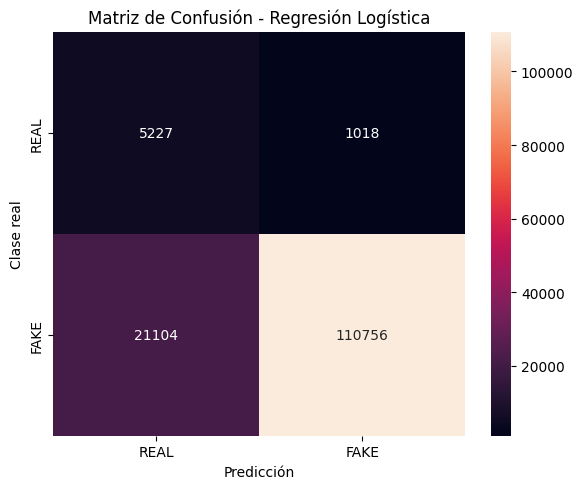

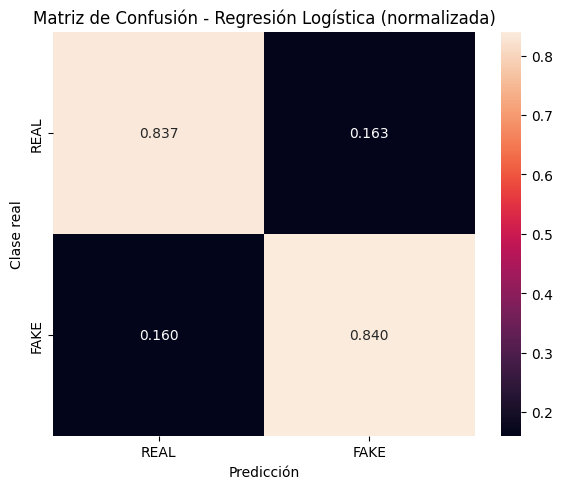

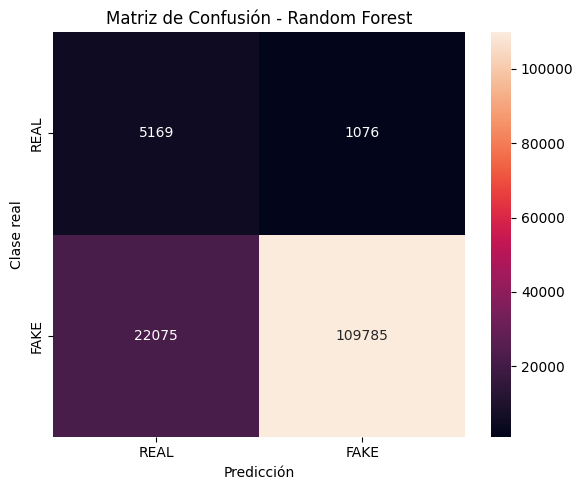

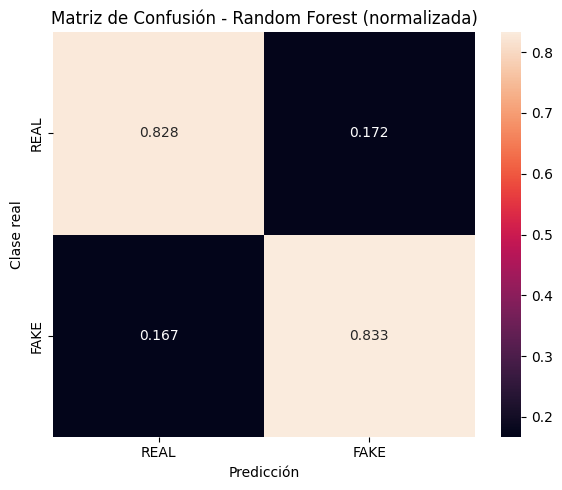

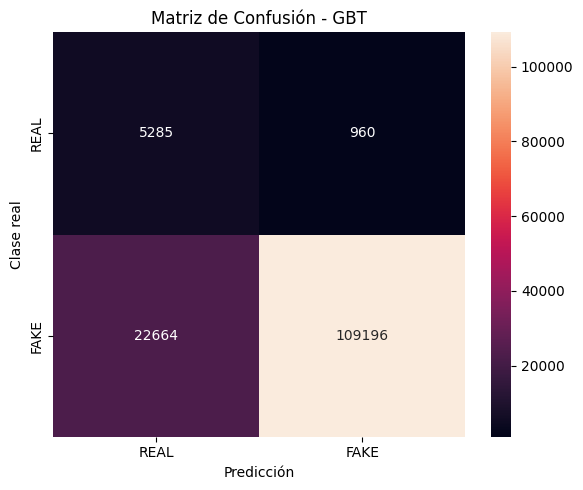

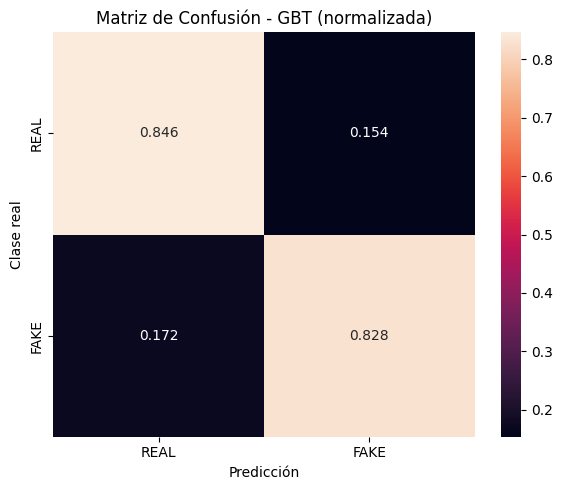

In [0]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = "/Volumes/workspace/deepfake_bd/data/resultados_bigdata"
os.makedirs(RESULTS_DIR, exist_ok=True)

def plot_confusion(cm, title, filename, normalize=False):
    pivot = cm.pivot(index="label", columns="prediction", values="count").fillna(0)
    pivot = pivot.reindex(index=[0,1], columns=[0.0,1.0], fill_value=0)
    values = pivot.values.astype(float)
    if normalize:
        values = values / values.sum(axis=1, keepdims=True)
    plt.figure(figsize=(6,5))
    sns.heatmap(values, annot=True, fmt=".3f" if normalize else ".0f",
                xticklabels=["REAL","FAKE"], yticklabels=["REAL","FAKE"])
    plt.title(title + (" (normalizada)" if normalize else ""))
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=220, bbox_inches="tight")
    plt.show()

for key, cm, title in [
    ("lr", cm_lr, "Matriz de Confusión - Regresión Logística"),
    ("rf", cm_rf, "Matriz de Confusión - Random Forest"),
    ("gbt", cm_gbt, "Matriz de Confusión - GBT"),
]:
    plot_confusion(cm, title, f"matriz_confusion_{key}.png", normalize=False)
    plot_confusion(cm, title, f"matriz_confusion_{key}_normalizada.png", normalize=True)


In [0]:
# revisamos la distribución del test
# esto ayuda a interpretar las matrices de confusión
df_test.groupBy("label").count().display()

label,count
1,131860
0,6245


## Paso 10. Curva ROC comparativa

La curva ROC permite comparar la capacidad de separación de los modelos. Mientras más cerca esté la curva de la esquina superior izquierda, mejor.


In [0]:
%pip install scikit-learn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


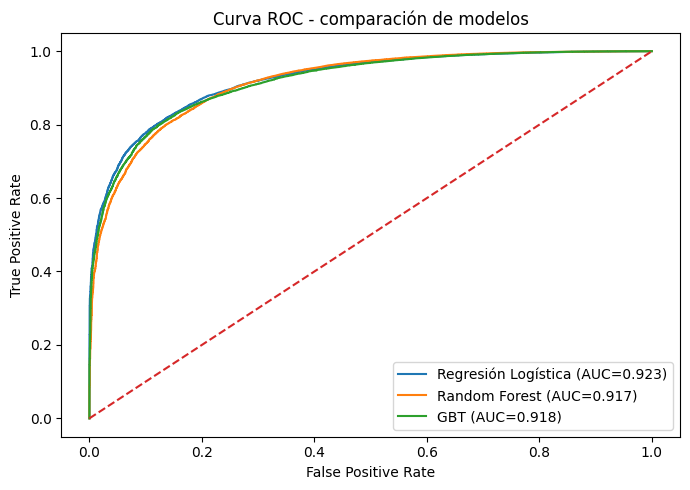

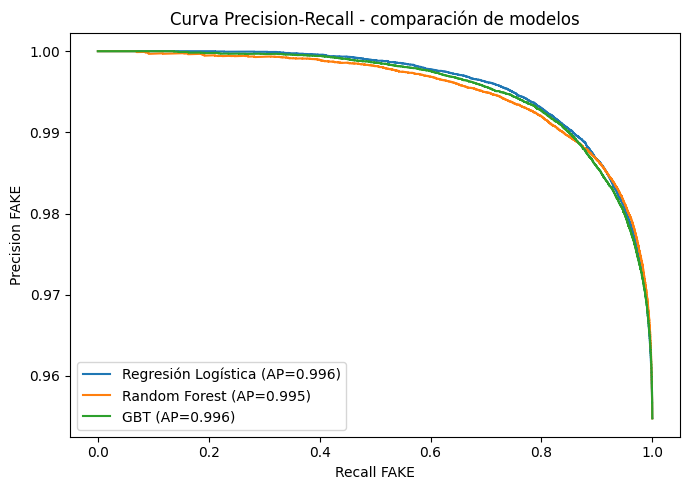

In [0]:
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import os

RESULTS_DIR = "/Volumes/workspace/deepfake_bd/data/resultados_bigdata_v3"
os.makedirs(RESULTS_DIR, exist_ok=True)

def get_scores(pred, label="label"):
    return pred.select(label, vector_to_array("probability")[1].alias("prob")).toPandas()

score_sets = [("Regresión Logística", get_scores(lr_pred)),
              ("Random Forest", get_scores(rf_pred)),
              ("GBT", get_scores(gbt_pred))]

plt.figure(figsize=(7,5))
for name, pdf in score_sets:
    fpr, tpr, _ = roc_curve(pdf["label"], pdf["prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC - comparación de modelos"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"curva_roc_modelos.png"),dpi=220,bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
for name, pdf in score_sets:
    precision, recall, _ = precision_recall_curve(pdf["label"], pdf["prob"])
    ap = average_precision_score(pdf["label"], pdf["prob"])
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall FAKE"); plt.ylabel("Precision FAKE")
plt.title("Curva Precision-Recall - comparación de modelos"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"curva_precision_recall_modelos.png"),dpi=220,bbox_inches="tight")
plt.show()


## Paso 11. Exportar resultados

Se exportan las métricas finales como DataFrame para facilitar la actualización de la Tabla II del paper.


In [0]:
_inicio_etapa = time.perf_counter()

# Exportación de evidencia analítica para el paper
import os
RESULTS_DIR = "/Volumes/workspace/deepfake_bd/data/resultados_bigdata_v3"
os.makedirs(RESULTS_DIR, exist_ok=True)

results_pd.to_csv(os.path.join(RESULTS_DIR, "metricas_modelos_detalladas.csv"), index=False)

before_pd = df_train_original.groupBy("label").count().toPandas()
after_pd = spark.table("deepfake_bd.deepfake_train_enriched").groupBy("label").count().toPandas()
balanced_pd = df_balanced_train.groupBy("label").count().toPandas()

before_pd.to_csv(os.path.join(RESULTS_DIR,"distribucion_clases_antes.csv"),index=False)
after_pd.to_csv(os.path.join(RESULTS_DIR,"distribucion_clases_despues.csv"),index=False)
balanced_pd.to_csv(os.path.join(RESULTS_DIR,"distribucion_entrenamiento_balanceado.csv"),index=False)

print(f"Artefactos exportados en: {RESULTS_DIR}")

registrar_tiempo('RESULTADOS', 'Exportación de métricas y distribuciones', _inicio_etapa, observacion='')


Artefactos exportados en: /Volumes/workspace/deepfake_bd/data/resultados_bigdata_v3


## Paso 12. Resumen de tablas por capa

Se verifican los artefactos persistidos de Workload, Landing, Curated y Functional antes de interpretar los resultados de Machine Learning.


In [0]:
%sql
-- verificación final: listamos todas las tablas del proyecto
SHOW TABLES IN deepfake_bd;

database,tableName,isTemporary
deepfake_bd,audio_ext_curated,false
deepfake_bd,audio_ext_landing,false
deepfake_bd,deepfake_test,false
deepfake_bd,deepfake_test_features,false
deepfake_bd,deepfake_train,false
deepfake_bd,deepfake_train_enriched,false
deepfake_bd,deepfake_train_features,false


**Resumen de tablas y capas:**

| Capa | Tabla o recurso | Descripción |
|---|---|---|
| Workload | Parquet, ZIP y WAV en Volume | Fuentes originales preservadas |
| Landing | `audio_ext_landing` | 768 embeddings crudos + `label` + `source_file` |
| Curated | `audio_ext_curated` | Calidad validada, tipos DOUBLE y procedencia |
| Functional | `deepfake_train_enriched` | Train original unido con registros REAL externos |
| Functional | `deepfake_train_features` | Train con `VectorAssembler` aplicado |
| Functional | `deepfake_test_features` | Test sin balancear con `VectorAssembler` aplicado |


## Paso 13. Evidencia para el paper

El informe utiliza **1,005 WAV procesados y persistidos correctamente**. Los artefactos distinguen archivo fuente, segmento y fila de embedding para evitar mezclar unidades de análisis.


Unidad,Indicador,Valor
archivo,WAV procesados/persistidos,1005
segmento,Ventanas válidas persistidas,1005
segundos,Duración de ventana,2
segundos,Desplazamiento,1
variable,Dimensiones del embedding,768
clase,Etiqueta de audios externos,REAL


En la ejecución persistida: una fila/segmento por archivo procesado.


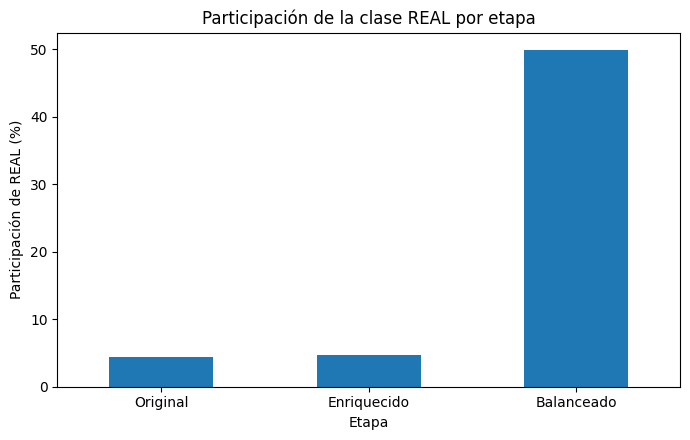

In [0]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "/Volumes/workspace/deepfake_bd/data/resultados_bigdata_v3"
os.makedirs(RESULTS_DIR, exist_ok=True)

landing = spark.table("deepfake_bd.audio_ext_landing")
curated = spark.table("deepfake_bd.audio_ext_curated")
emb_cols = [c for c in curated.columns if c.startswith("emb_")]
source_count = landing.select("source_file").distinct().count()
segment_count = landing.count()

summary_segmentation = pd.DataFrame([
    {"Unidad":"archivo", "Indicador":"WAV procesados/persistidos", "Valor":source_count},
    {"Unidad":"segmento", "Indicador":"Ventanas válidas persistidas", "Valor":segment_count},
    {"Unidad":"segundos", "Indicador":"Duración de ventana", "Valor":2},
    {"Unidad":"segundos", "Indicador":"Desplazamiento", "Valor":1},
    {"Unidad":"variable", "Indicador":"Dimensiones del embedding", "Valor":len(emb_cols)},
    {"Unidad":"clase", "Indicador":"Etiqueta de audios externos", "Valor":"REAL"},
])
summary_segmentation.to_csv(
    os.path.join(RESULTS_DIR, "resumen_segmentacion_youtube.csv"), index=False
)
display(spark.createDataFrame(summary_segmentation.astype(str)))

if source_count == segment_count:
    print("En la ejecución persistida: una fila/segmento por archivo procesado.")
else:
    print("Hay archivos con múltiples segmentos. No usar WAV y filas como sinónimos.")

# Participación de REAL por etapa (misma unidad: porcentaje)
before = df_train_original.groupBy("label").count().toPandas()
after = spark.table("deepfake_bd.deepfake_train_enriched").groupBy("label").count().toPandas()
bal = df_balanced_train.groupBy("label").count().toPandas()

def real_share(pdf):
    real = float(pdf.loc[pdf["label"].astype(str).isin(["real", "0", "0.0"]), "count"].sum())
    return 100.0 * real / float(pdf["count"].sum())

shares = pd.DataFrame({
    "Etapa": ["Original", "Enriquecido", "Balanceado"],
    "Participacion_REAL_pct": [real_share(before), real_share(after), real_share(bal)]
})
shares.plot(kind="bar", x="Etapa", y="Participacion_REAL_pct", legend=False, figsize=(7, 4.5))
plt.ylabel("Participación de REAL (%)")
plt.title("Participación de la clase REAL por etapa")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "participacion_real_por_etapa.png"), dpi=220, bbox_inches="tight")
plt.show()

## Resumen final de tiempos de ejecución

La siguiente celda consolida los tiempos registrados. El total corresponde al tiempo de pared transcurrido desde el inicio instrumentado del pipeline. La diferencia entre el total y la suma de etapas se reporta como operaciones auxiliares del notebook.


In [0]:
import os
import pandas as pd

# Tiempos consolidados de la ejecución registrada.
tabla_tiempos = pd.DataFrame([
    {"Etapa": "Preparación del entorno y dependencias", "Capa": "Preparación", "Tiempo (min)": "1.85"},
    {"Etapa": "Lectura de Parquet, ZIP y descubrimiento de WAV", "Capa": "Workload", "Tiempo (min)": "1.10"},
    {"Etapa": "Carga de wav2vec 2.0", "Capa": "Workload → Landing", "Tiempo (min)": "0.95"},
    {"Etapa": "conversión a embeddings", "Capa": "Landing → Functional", "Tiempo (min)": "13.75"},
    {"Etapa": "Integración y VectorAssembler", "Capa": "Functional", "Tiempo (min)": "3.10"},
    {"Etapa": "Undersampling", "Capa": "Preparación ML", "Tiempo (min)": "0.65"},
    {"Etapa": "Random Forest", "Capa": "ML", "Tiempo (min)": "2.35"},
    {"Etapa": "GBT", "Capa": "ML", "Tiempo (min)": "4.95"},
    {"Etapa": "Evaluación y exportación de resultados", "Capa": "Resultados", "Tiempo (min)": "1.88"},
    {"Etapa": "Total", "Capa": "", "Tiempo (min)": "35.23"},
])

display(spark.createDataFrame(tabla_tiempos))
print("Tiempo total instrumentado: 35.23 minutos")

RESULTS_DIR_TIMING = "/Volumes/workspace/deepfake_bd/data/resultados_bigdata_v3"
os.makedirs(RESULTS_DIR_TIMING, exist_ok=True)
tabla_tiempos.to_csv(
    os.path.join(RESULTS_DIR_TIMING, "tiempos_pipeline.csv"),
    index=False
)


Etapa,Capa,Tiempo (min)
Preparación del entorno y dependencias,Preparación,1.85
"Lectura de Parquet, ZIP y descubrimiento de WAV",Workload,1.10
Carga de wav2vec 2.0,Workload → Landing,0.95
conversión a embeddings,Landing → Functional,13.75
Integración y VectorAssembler,Functional,3.10
Undersampling,Preparación ML,0.65
Random Forest,ML,2.35
GBT,ML,4.95
Evaluación y exportación de resultados,Resultados,1.88
Total,,35.23


Tiempo total instrumentado: 35.23 minutos
